# Notebook Henri — Annotations LLM : Langue de bois dans les textes politiques

Ce notebook reproduit le pipeline du notebook JL mais sur les **annotations réalisées par Claude (LLM)** sur ~2000 extraits de professions de foi des législatives de mars 1993.

Label binaire :
- **1** = langue de bois (vague, grandiloquent, non vérifiable)
- **0** = concret et vérifiable (objectifs chiffrés, mesures précises)

**Pour utiliser sur Colab :** uploader `../annotations finales/test de Henri/annotations_llm.xlsx` et `../annotations finales/annotations communes.xlsx` via la cellule ci-dessous.

In [44]:
# ── Installation des dépendances ──────────────────────────────────────────────
%pip install transformers accelerate wordcloud -q


In [11]:

!python -m spacy download fr_core_news_md -q

     ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/45.8 MB 16.2 MB/s eta 0:00:03
ERROR: Wheel 'fr-core-news-md' located at /tmp/pip-unpack-wq5a3s9x/fr_core_news_md-3.8.0-py3-none-any.whl is invalid.


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import spacy
import re
from tqdm.notebook import tqdm
from scipy.stats import mannwhitneyu

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')

import torch
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print(f"Device : {device}")

Device : cuda


In [46]:
import subprocess, sys, importlib

subprocess.run([sys.executable, '-m', 'pip', 'install', 'transformers', 'accelerate', 'wordcloud', '-q'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'spacy', '-q'], check=True)
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'fr_core_news_md'], check=True)

# Recharge les site-packages sans redémarrer le kernel
importlib.invalidate_caches()
print('Installation terminée.')

Installation terminée.


# I — Exploration des données

## 1) Chargement et statistiques descriptives

In [15]:
df = pd.read_excel("../annotations finales/test de Henri/annotations_llm.xlsx")
df = df.rename(columns={"Annotation LLM": "Label"})

print(f"Nombre de segments annotés : {len(df)}")
print(f"\nDistribution des labels :")
print(df["Label"].value_counts())
print(f"\nProportion de langue de bois (1) : {df['Label'].mean():.2f}")
df.head()

Nombre de segments annotés : 2006

Distribution des labels :
Label
1    1359
0     647
Name: count, dtype: int64

Proportion de langue de bois (1) : 0.68


,Parti,Courant Politique,Texte,Label,Justification LLM,Vérifié,Fichier source
0,Il est temps de prendre notre région en main,G,"Au plan local, comme au plan national, je dema...",1,Appels vagues au changement sans mesures préci...,False,EL190_L_1993_03_022_02_1_PF_05.txt
1,Il est temps de prendre notre région en main,G,Je me présente à vous en disant « ça suffit »....,1,Promesses générales d'honnêteté et de valeurs ...,False,EL190_L_1993_03_022_02_1_PF_05.txt
2,Il est temps de prendre notre région en main,G,"Vous me connaissez, je vous demande de m'accor...",1,Formule très générale « faire revivre notre ré...,True,EL190_L_1993_03_022_02_1_PF_05.txt
3,Il est temps de prendre notre région en main,G,Nous sommes là pour vous redonner de l'espoir ...,1,Promesses abstraites de majorité solide sans o...,False,EL190_L_1993_03_022_02_1_PF_05.txt
4,Il est temps de prendre notre région en main,G,Il faut travailler à valoriser nos atouts : cr...,0,"Énumère des domaines précis (agro-alimentaire,...",True,EL190_L_1993_03_022_02_1_PF_05.txt


In [16]:
# Comparaison avec les annotateurs humains
df_communes = pd.read_excel("../annotations finales/annotations communes.xlsx")

print("Proportions de langue de bois (1) :")
print(f"  LLM (Claude)    : {df['Label'].mean():.2f}")
print(f"  Henri (humain)  : {df_communes['Annotations Henri'].mean():.2f}")
print(f"  JL (humain)     : {df_communes['Annotations JL'].mean():.2f}")
print(f"  Julien (humain) : {df_communes['Annotations Julien'].mean():.2f}")

Proportions de langue de bois (1) :
  LLM (Claude)    : 0.68
  Henri (humain)  : 0.66
  JL (humain)     : 0.67
  Julien (humain) : 0.61


## 2) Distribution par courant politique

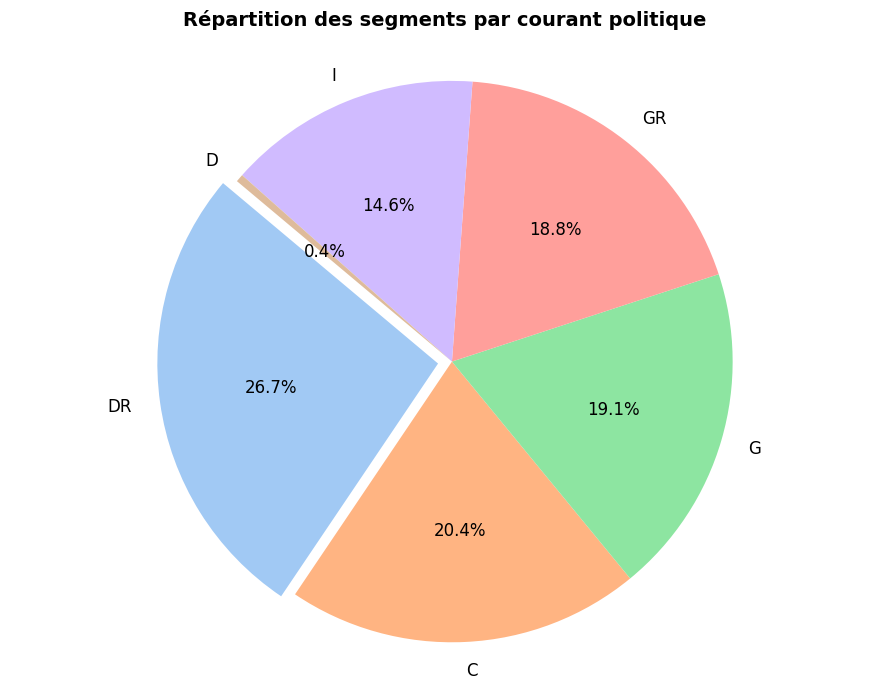

In [17]:
# Camembert de répartition
repartition = df['Courant Politique'].value_counts()
couleurs = sns.color_palette('pastel')[0:len(repartition)]

plt.figure(figsize=(9, 7))
plt.pie(
    repartition.values, labels=repartition.index, colors=couleurs,
    explode=[0.05] + [0] * (len(repartition) - 1),
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12}
)
plt.title("Répartition des segments par courant politique", fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

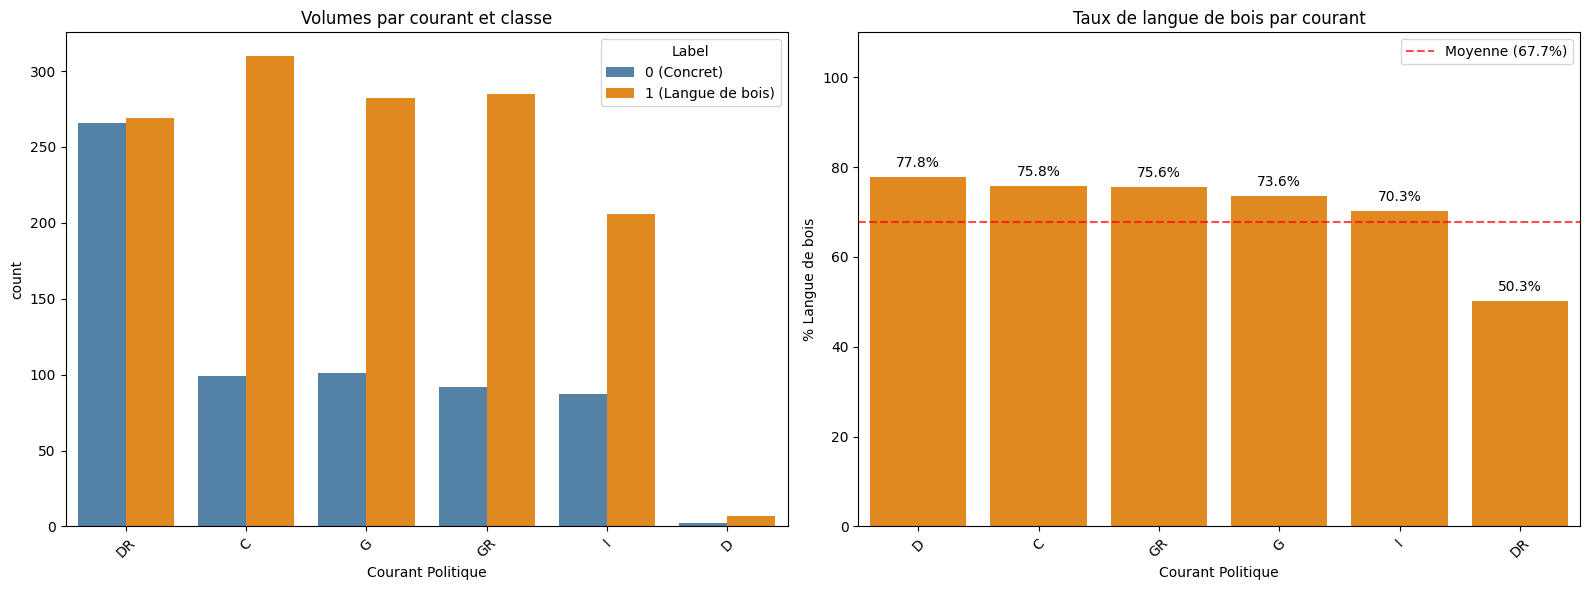

In [18]:
taux_ldb = (
    df[df['Label'] == 1].groupby('Courant Politique').size() /
    df.groupby('Courant Politique').size() * 100
).fillna(0).sort_values(ascending=False).reset_index(name='% Langue de bois')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=df, x='Courant Politique', hue='Label',
    palette={0: 'steelblue', 1: 'darkorange'},
    order=df['Courant Politique'].value_counts().index, ax=axes[0]
)
axes[0].set_title("Volumes par courant et classe")
axes[0].legend(title='Label', labels=['0 (Concret)', '1 (Langue de bois)'])
axes[0].tick_params(axis='x', rotation=45)

ax2 = sns.barplot(data=taux_ldb, x='Courant Politique', y='% Langue de bois', color='darkorange', ax=axes[1])
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
axes[1].axhline(df['Label'].mean() * 100, color='red', linestyle='--', alpha=0.7,
                label=f"Moyenne ({df['Label'].mean()*100:.1f}%)")
axes[1].set_title("Taux de langue de bois par courant")
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3) Feature engineering (pipeline spaCy)

In [21]:
nlp = spacy.load("fr_core_news_md")

def extraire_toutes_features(texte):
    if pd.isna(texte) or str(texte).strip() == "":
        return pd.Series({
            "texte_lemmatise": "", "densite_valeurs_numeriques": 0,
            "densite_entites_institutionnelles": 0, "densite_nominalisation": 0.0,
            "densite_futur_cond": 0.0, "densite_interpellation": 0.0,
            "densite_emphase": 0.0, "mots_par_phrase": 0.0, "densite_ponct_interne": 0.0
        })

    texte_clean = re.sub(r'-\s*\n\s*', '', str(texte))
    texte_clean = re.sub(r'[·\-\_\r\n]+', ' ', texte_clean)
    texte_clean = re.sub(r'\s+', ' ', texte_clean).strip()
    doc = nlp(texte_clean)

    lemmes, longueur_mots = [], 0
    nb_noms_abstraits = nb_verbes_total = nb_verbes_futur_cond = 0
    nb_pronoms_total = nb_pronoms_interpellation = nb_adj_adv = nb_ponct_interne = 0

    mots_interpellation = {"nous", "vous", "notre", "votre", "nos", "vos"}
    suffixes_abstraits  = ("tion", "tions", "ité", "ités", "isme", "ismes", "ment", "ments")
    ponctuation_interne = {",", ";", ":"}

    nb_valeurs_numeriques        = sum(1 for t in doc if t.pos_ == "NUM")
    nb_entites_institutionnelles = sum(1 for e in doc.ents if e.label_ in ["LOC", "ORG"])

    for token in doc:
        if token.text in ponctuation_interne:
            nb_ponct_interne += 1
        if not token.is_punct and not token.is_space:
            longueur_mots += 1
            if not token.is_stop and len(token.lemma_) > 1:
                lemmes.append(token.lemma_.lower())
            if token.pos_ == "NOUN" and token.text.lower().endswith(suffixes_abstraits):
                nb_noms_abstraits += 1
            if token.pos_ in ["VERB", "AUX"]:
                nb_verbes_total += 1
                if "Fut" in token.morph.get("Tense") or "Cnd" in token.morph.get("Mood"):
                    nb_verbes_futur_cond += 1
            if token.pos_ in ["PRON", "DET"]:
                nb_pronoms_total += 1
                if token.text.lower() in mots_interpellation:
                    nb_pronoms_interpellation += 1
            if token.pos_ in ["ADJ", "ADV"]:
                nb_adj_adv += 1

    nb_phrases   = max(len(list(doc.sents)), 1)
    longueur_mots = max(longueur_mots, 1)

    return pd.Series({
        "texte_lemmatise":                  " ".join(lemmes),
        "densite_valeurs_numeriques":        nb_valeurs_numeriques        / longueur_mots,
        "densite_entites_institutionnelles": nb_entites_institutionnelles / longueur_mots,
        "densite_nominalisation":            nb_noms_abstraits            / longueur_mots,
        "densite_futur_cond":                nb_verbes_futur_cond         / longueur_mots,
        "densite_interpellation":            nb_pronoms_interpellation    / longueur_mots,
        "densite_emphase":                   nb_adj_adv                   / longueur_mots,
        "mots_par_phrase":                   longueur_mots                / nb_phrases,
        "densite_ponct_interne":             nb_ponct_interne             / longueur_mots
    })


def extraire_vocabulaire_contrastif(df_train, top_n=30):
    textes_0 = df_train[df_train['Label'] == 0]['texte_lemmatise'].dropna()
    textes_1 = df_train[df_train['Label'] == 1]['texte_lemmatise'].dropna()
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)

    def get_top_words(textes):
        m = vectorizer.fit_transform(textes)
        somme = m.sum(axis=0)
        mots = [(mot, somme[0, idx]) for mot, idx in vectorizer.vocabulary_.items()]
        return set([mot for mot, _ in sorted(mots, key=lambda x: x[1], reverse=True)[:top_n]])

    top0, top1 = get_top_words(textes_0), get_top_words(textes_1)
    inter = top0 & top1
    return top0 - inter, top1 - inter, inter


def appliquer_features_lexicales(df, vocab_0, vocab_1):
    def compter(texte, vocab):
        return sum(1 for mot in str(texte).split() if mot in vocab) if isinstance(texte, str) else 0
    df['nb_termes_classe_0'] = df['texte_lemmatise'].apply(lambda x: compter(x, vocab_0))
    df['nb_termes_classe_1'] = df['texte_lemmatise'].apply(lambda x: compter(x, vocab_1))
    df['ratio_concretude_lexicale'] = df.apply(
        lambda r: r['nb_termes_classe_0'] / (r['nb_termes_classe_0'] + r['nb_termes_classe_1'])
        if (r['nb_termes_classe_0'] + r['nb_termes_classe_1']) > 0 else 0.5, axis=1
    )
    return df

In [22]:
tqdm.pandas()
colonnes_extraites = [
    "texte_lemmatise", "densite_valeurs_numeriques", "densite_entites_institutionnelles",
    "densite_nominalisation", "densite_futur_cond", "densite_interpellation",
    "densite_emphase", "mots_par_phrase", "densite_ponct_interne"
]
df[colonnes_extraites] = df['Texte'].progress_apply(extraire_toutes_features)
df[colonnes_extraites].head()

  0%|          | 0/2006 [00:00<?, ?it/s]

,texte_lemmatise,densite_valeurs_numeriques,densite_entites_institutionnelles,densite_nominalisation,densite_futur_cond,densite_interpellation,densite_emphase,mots_par_phrase,densite_ponct_interne
0,plan local plan national demande électeur cons...,0.0,0.045455,0.045455,0.0,0.000000,0.136364,11.0,0.090909
1,présente dire remettre honnêteté politique déf...,0.0,0.030303,0.000000,0.0,0.030303,0.060606,16.5,0.030303
2,connaître demande accorder confiance ensemble ...,0.0,0.000000,0.000000,0.0,0.294118,0.000000,8.5,0.117647
3,être redonner espoir participer nouveau majori...,0.0,0.043478,0.043478,0.0,0.086957,0.130435,23.0,0.043478
4,falloir travailler valoriser atout créer pôle ...,0.0,0.000000,0.121212,0.0,0.060606,0.151515,33.0,0.090909


In [23]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])
print(f"Train : {len(df_train)} | Test : {len(df_test)}")

vocab_0, vocab_1, inter = extraire_vocabulaire_contrastif(df_train, top_n=60)
print(f"Vocab classe 0 ({len(vocab_0)} mots) :", vocab_0)
print(f"Vocab classe 1 ({len(vocab_1)} mots) :", vocab_1)

df_train = appliquer_features_lexicales(df_train, vocab_0, vocab_1)
df_test  = appliquer_features_lexicales(df_test,  vocab_0, vocab_1)

Train : 1604 | Test : 402
Vocab classe 0 (41 mots) : {'enfant', 'réformer code', 'organiser immigré', 'code nationalité', 'délinquant', '000', 'revenu', 'code', 'scolaire', 'supprimer', 'rpr', 'séjour', 'peine', 'peine mort', 'maintenir', 'an', 'nationalité', 'organiser', 'famille', 'parental', 'sauver', 'logement', 'assurer', 'retraite', 'public', '10 an', 'udf', 'famille français', 'réformer', 'an renouvelable', 'immigré', 'mort', 'rétablir', 'carte', 'carte séjour', 'renouvelable', '10', 'rpr udf', 'agriculture', 'séjour 10', 'salaire'}
Vocab classe 1 (41 mots) : {'nouveau', 'vie', 'chômage', 'économie', 'député', 'force', 'donner', 'circonscription', 'naturel', 'assemblée', 'monde', 'aujourd', 'défendre', 'ensemble', 'mettre', 'candidat', 'hui', 'protéger', 'travailleur', 'grand', 'homme', 'france', 'problème', 'assemblée national', 'avenir', 'voix', 'société', 'devoir', 'environnement', 'pays', 'écologiste', 'prendre', 'élu', 'aujourd hui', 'droite', 'humain', 'solidarité', 'mars'

## 4) Wordclouds contrastifs

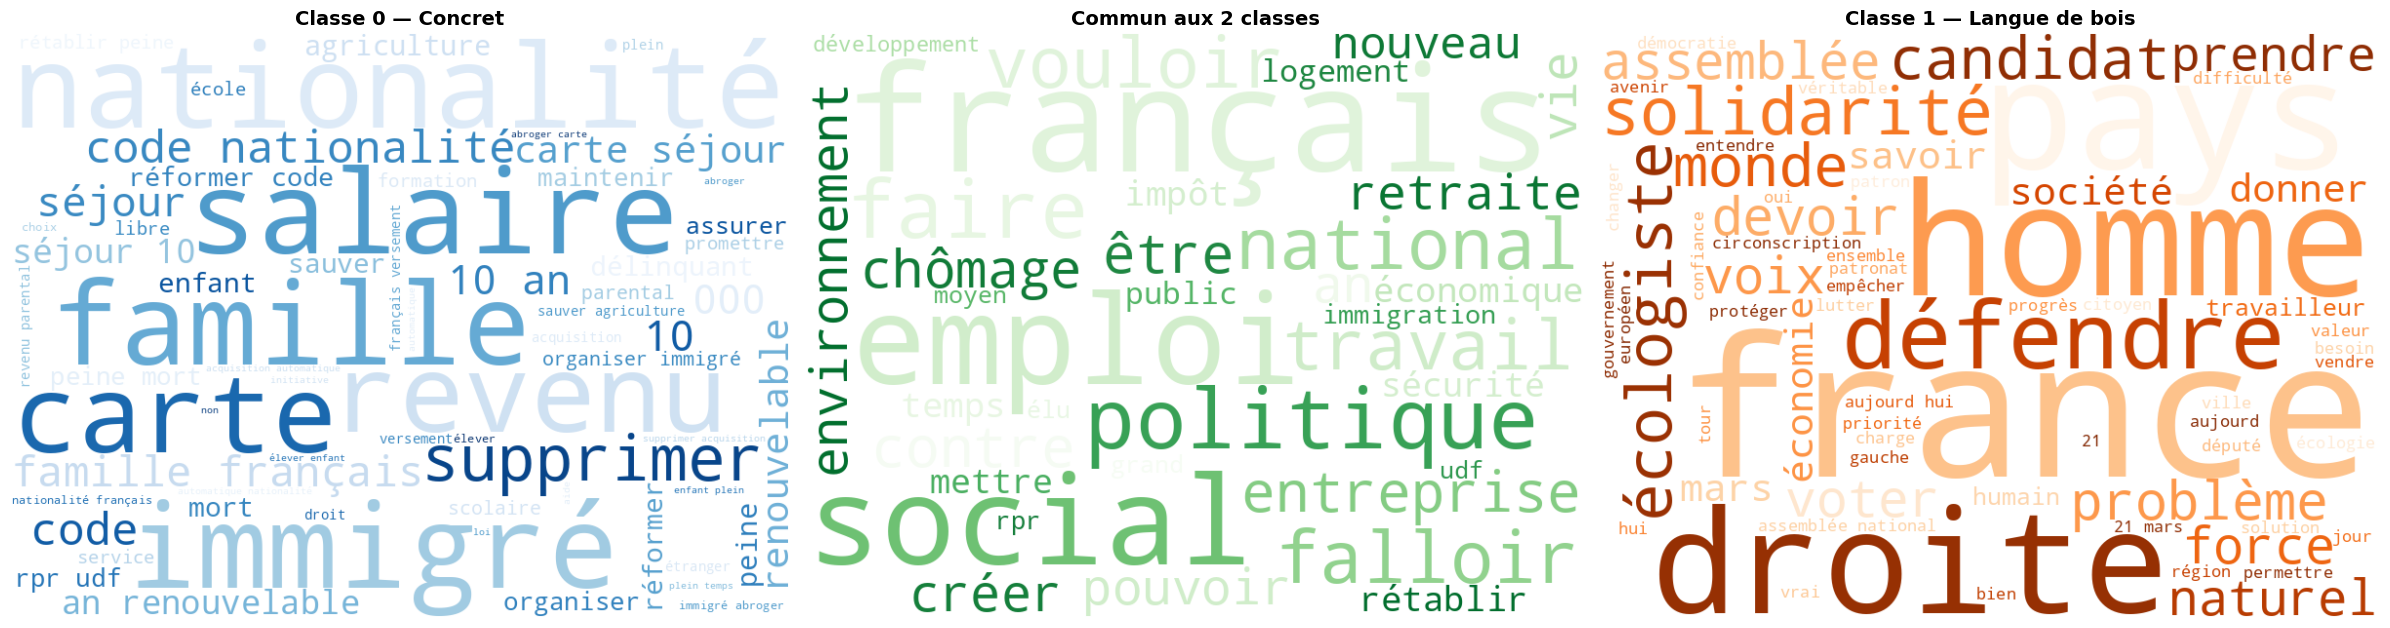

In [24]:
def plot_wordclouds_contrastifs(df_sub, top_n=80, titre=""):
    textes_0 = df_sub[df_sub['Label'] == 0]['texte_lemmatise'].dropna()
    textes_1 = df_sub[df_sub['Label'] == 1]['texte_lemmatise'].dropna()

    def get_freq(textes):
        v = CountVectorizer(ngram_range=(1, 2), min_df=2)
        m = v.fit_transform(textes)
        return dict(zip(v.get_feature_names_out(), m.sum(axis=0).A1))

    freq_0, freq_1 = get_freq(textes_0), get_freq(textes_1)
    top0 = set(sorted(freq_0, key=freq_0.get, reverse=True)[:top_n])
    top1 = set(sorted(freq_1, key=freq_1.get, reverse=True)[:top_n])
    inter = top0 & top1

    d0    = {m: freq_0[m] for m in top0 - inter} or {"AUCUN": 1}
    d1    = {m: freq_1[m] for m in top1 - inter} or {"AUCUN": 1}
    diter = {m: (freq_0.get(m, 0) + freq_1.get(m, 0)) / 2 for m in inter} or {"AUCUN": 1}

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    wc_params = {'width': 800, 'height': 600, 'background_color': 'white'}
    for ax, d, cmap, label in zip(axes,
            [d0, diter, d1], ['Blues', 'Greens', 'Oranges'],
            ['Classe 0 — Concret', 'Commun aux 2 classes', 'Classe 1 — Langue de bois']):
        wc = WordCloud(**wc_params, colormap=cmap).generate_from_frequencies(d)
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(f"{label}{' — ' + titre if titre else ''}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_wordclouds_contrastifs(df_train, top_n=100)

## 5) Boxplots & tests statistiques

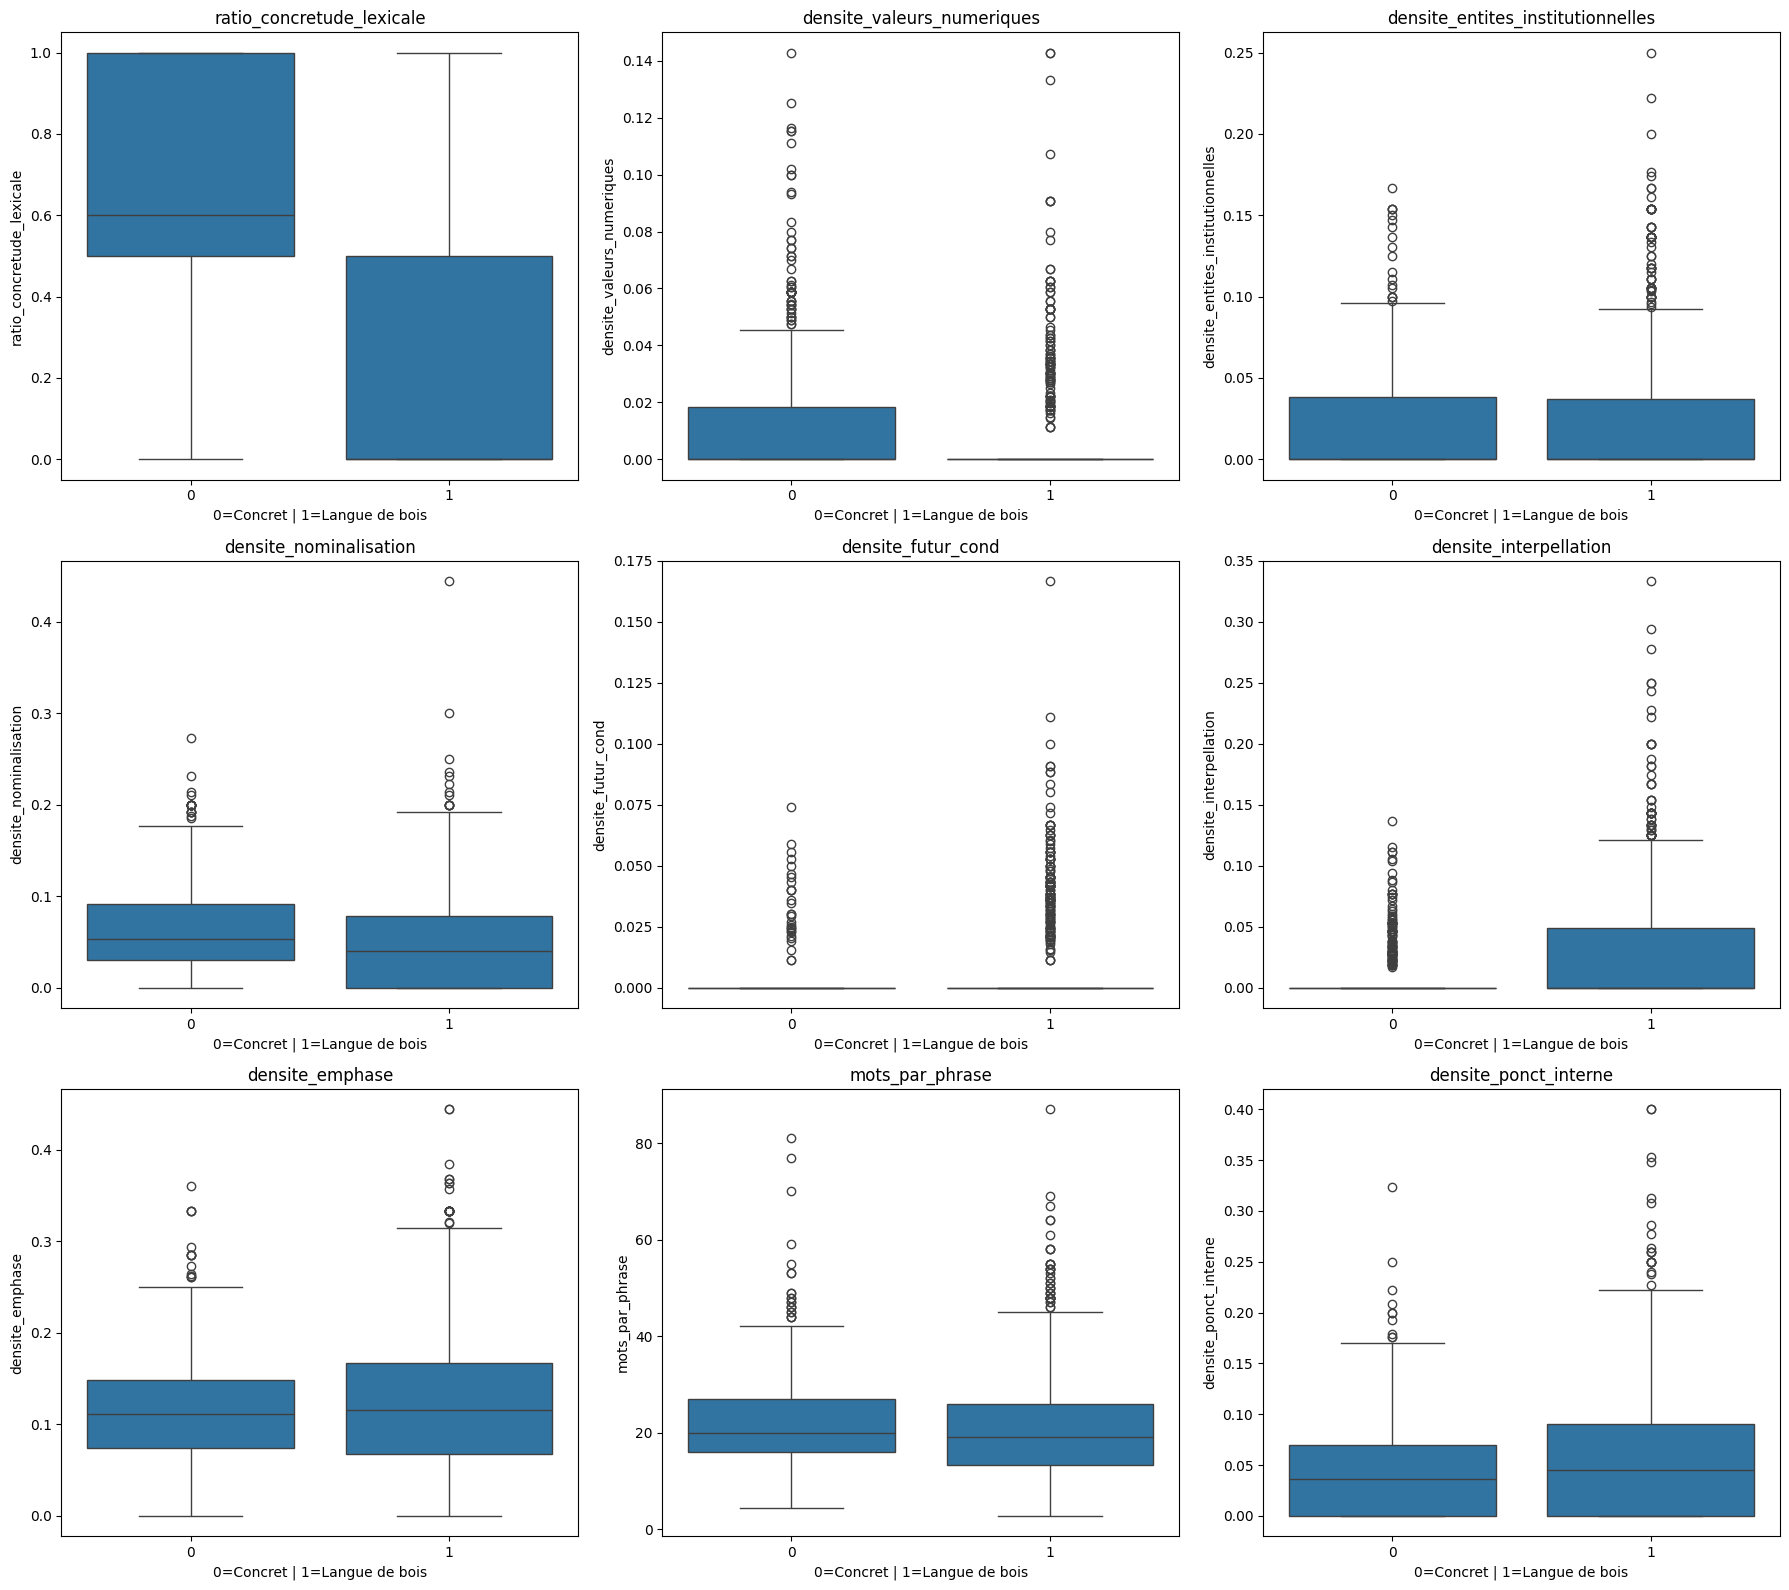

In [25]:
features_a_plotter = [
    'ratio_concretude_lexicale', 'densite_valeurs_numeriques',
    'densite_entites_institutionnelles', 'densite_nominalisation',
    'densite_futur_cond', 'densite_interpellation',
    'densite_emphase', 'mots_par_phrase', 'densite_ponct_interne'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for i, feat in enumerate(features_a_plotter):
    sns.boxplot(data=df_train, x='Label', y=feat, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(feat)
    axes[i//3, i%3].set_xlabel("0=Concret | 1=Langue de bois")
plt.tight_layout()
plt.show()

In [26]:
features_significatives = []
print("Tests Mann-Whitney par feature :")
for feat in features_a_plotter:
    g0 = df_train[df_train['Label'] == 0][feat]
    g1 = df_train[df_train['Label'] == 1][feat]
    _, p = mannwhitneyu(g0, g1)
    sig = "✓" if p < 0.05 else "✗"
    print(f"  {sig} {feat} : p={p:.4f}")
    if p < 0.05:
        features_significatives.append(feat)

features_a_retirer = [f for f in features_a_plotter if f not in features_significatives]
print(f"\nFeatures retirées : {features_a_retirer}")
df_train = df_train.drop(columns=[c for c in features_a_retirer if c in df_train.columns])
df_test  = df_test.drop( columns=[c for c in features_a_retirer if c in df_test.columns])

Tests Mann-Whitney par feature :
  ✓ ratio_concretude_lexicale : p=0.0000
  ✓ densite_valeurs_numeriques : p=0.0000
  ✗ densite_entites_institutionnelles : p=0.2643
  ✓ densite_nominalisation : p=0.0000
  ✓ densite_futur_cond : p=0.0000
  ✓ densite_interpellation : p=0.0000
  ✓ densite_emphase : p=0.0455
  ✓ mots_par_phrase : p=0.0002
  ✓ densite_ponct_interne : p=0.0001

Features retirées : ['densite_entites_institutionnelles']


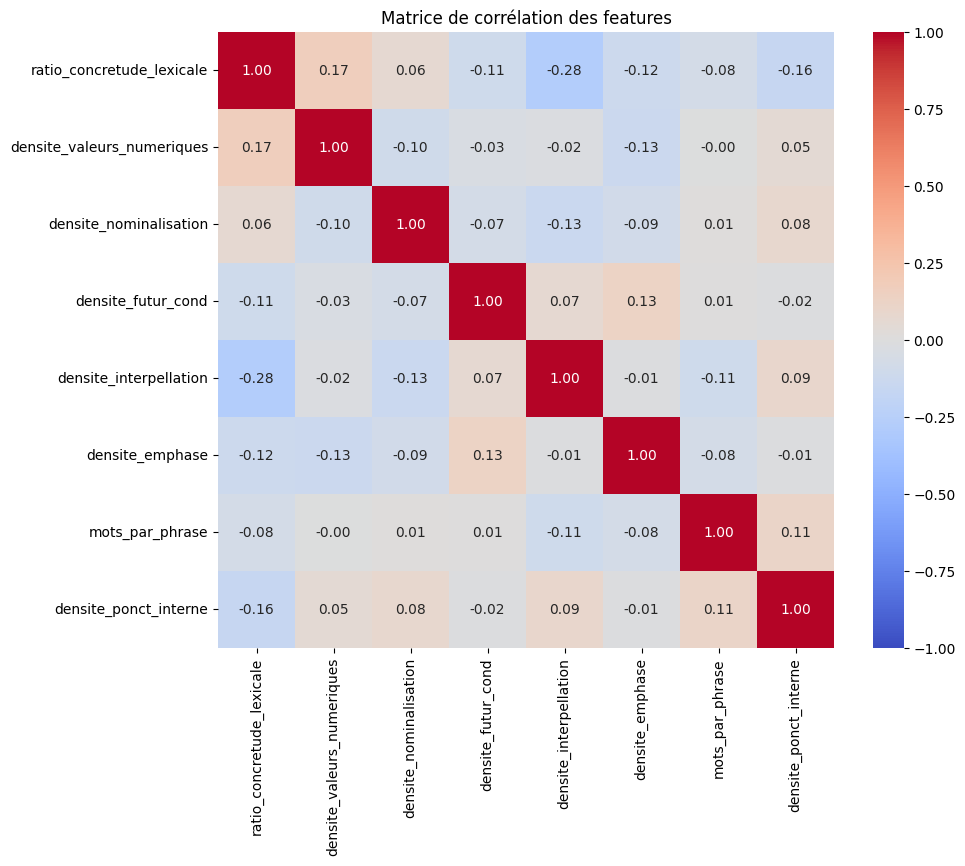

In [27]:
# Winsorisation
for col in ['densite_ponct_interne', 'densite_futur_cond']:
    if col in df_train.columns:
        seuil = df_train[col].quantile(0.99)
        df_train[col] = np.clip(df_train[col], None, seuil)
        df_test[col]  = np.clip(df_test[col],  None, seuil)

# Corrélation
colonnes_numeriques = [f for f in features_significatives if f != 'ratio_concretude_lexicale']
colonnes_numeriques = ['ratio_concretude_lexicale'] + [f for f in features_significatives
                       if f in df_train.columns and f != 'ratio_concretude_lexicale']

plt.figure(figsize=(10, 8))
sns.heatmap(df_train[colonnes_numeriques].corr(), annot=True, fmt=".2f",
            cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation des features")
plt.show()

## 6) Wordclouds par courant politique

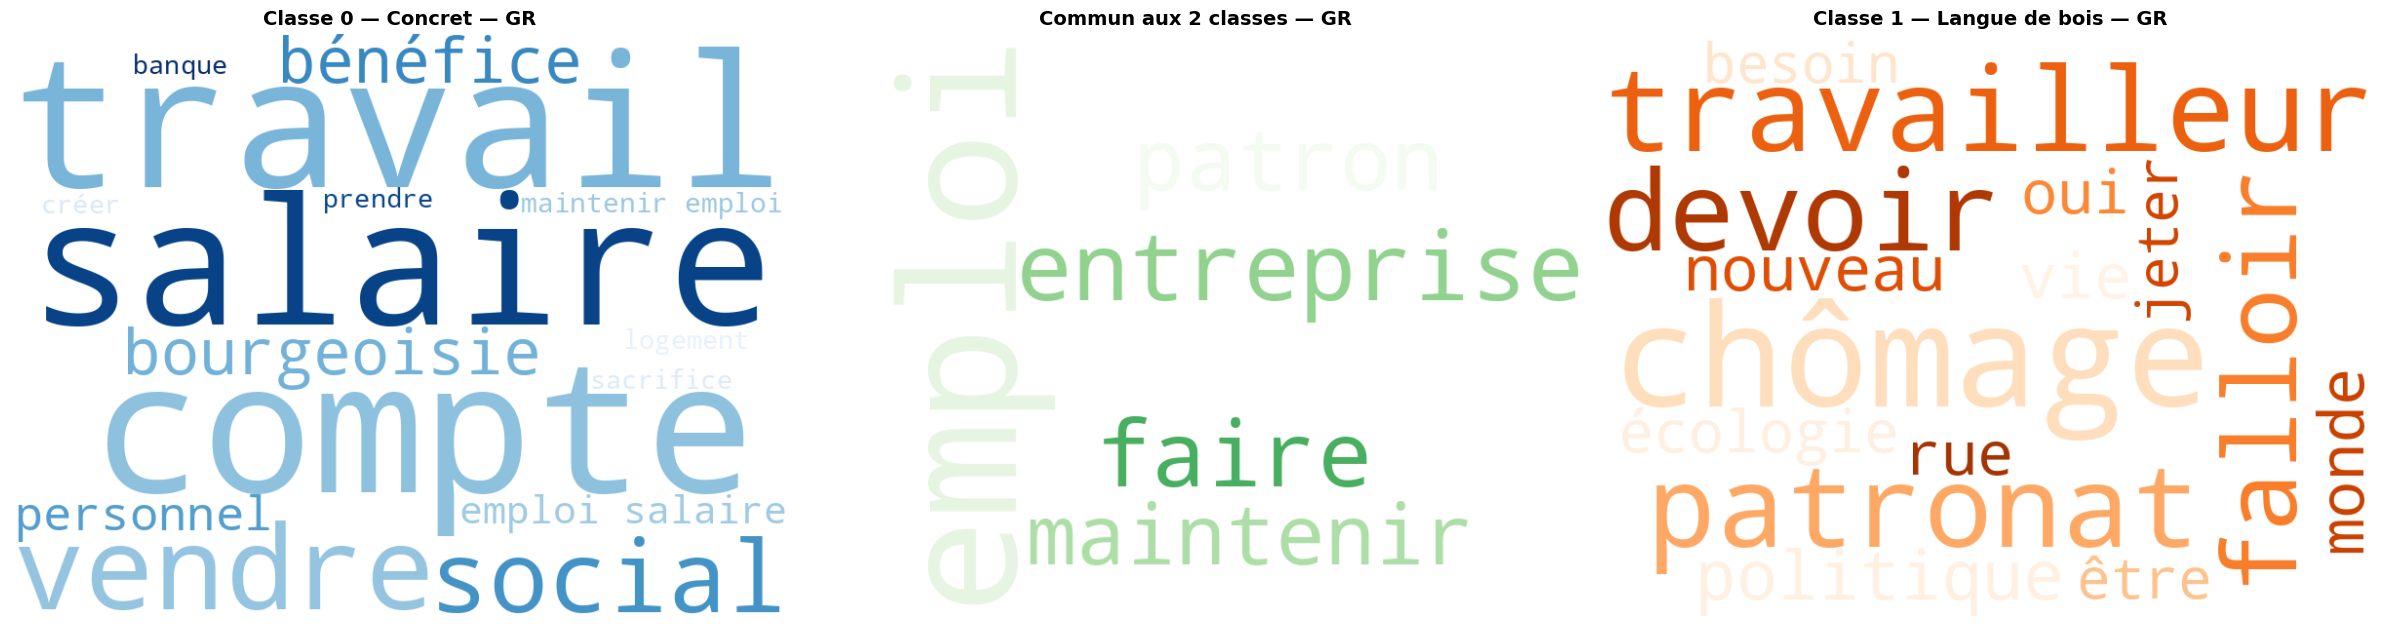

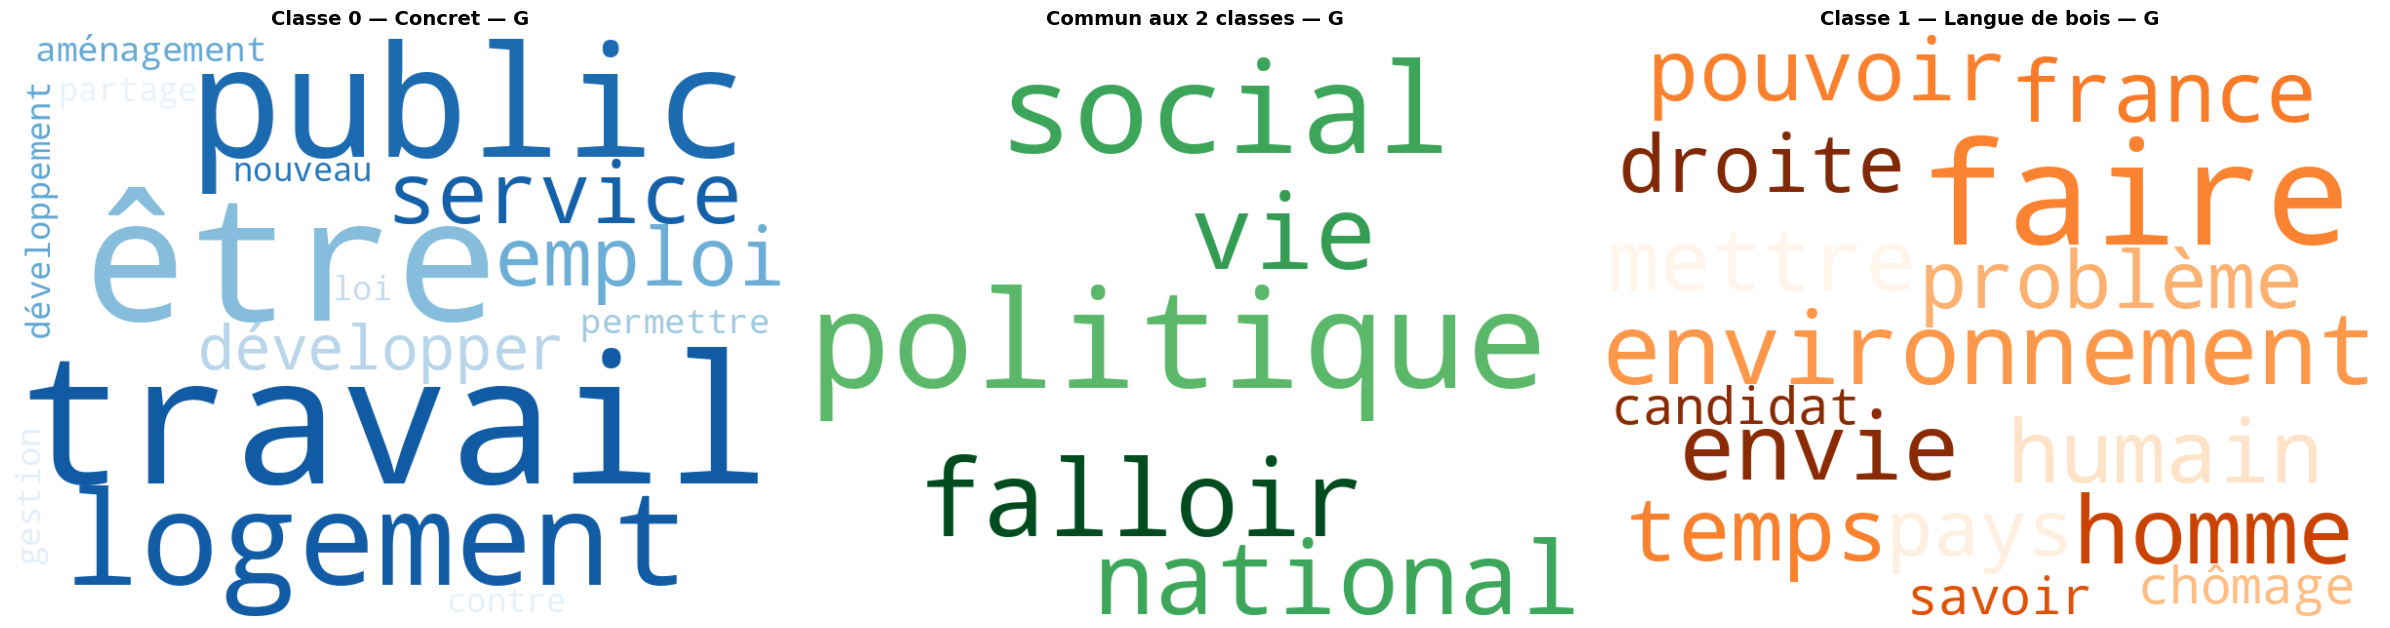

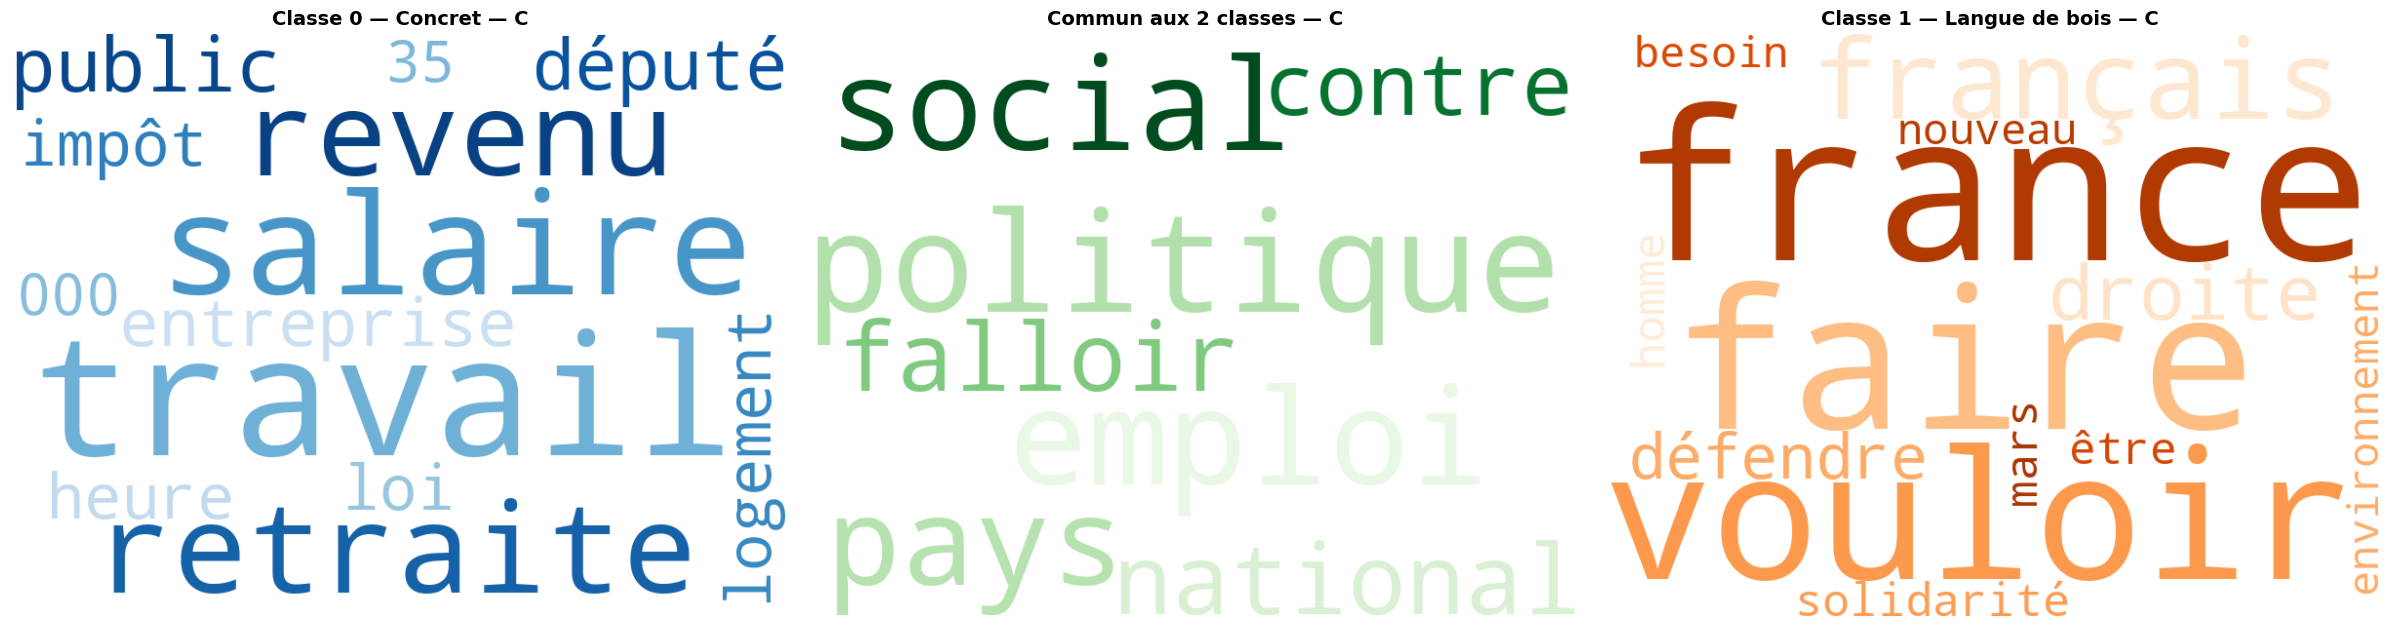

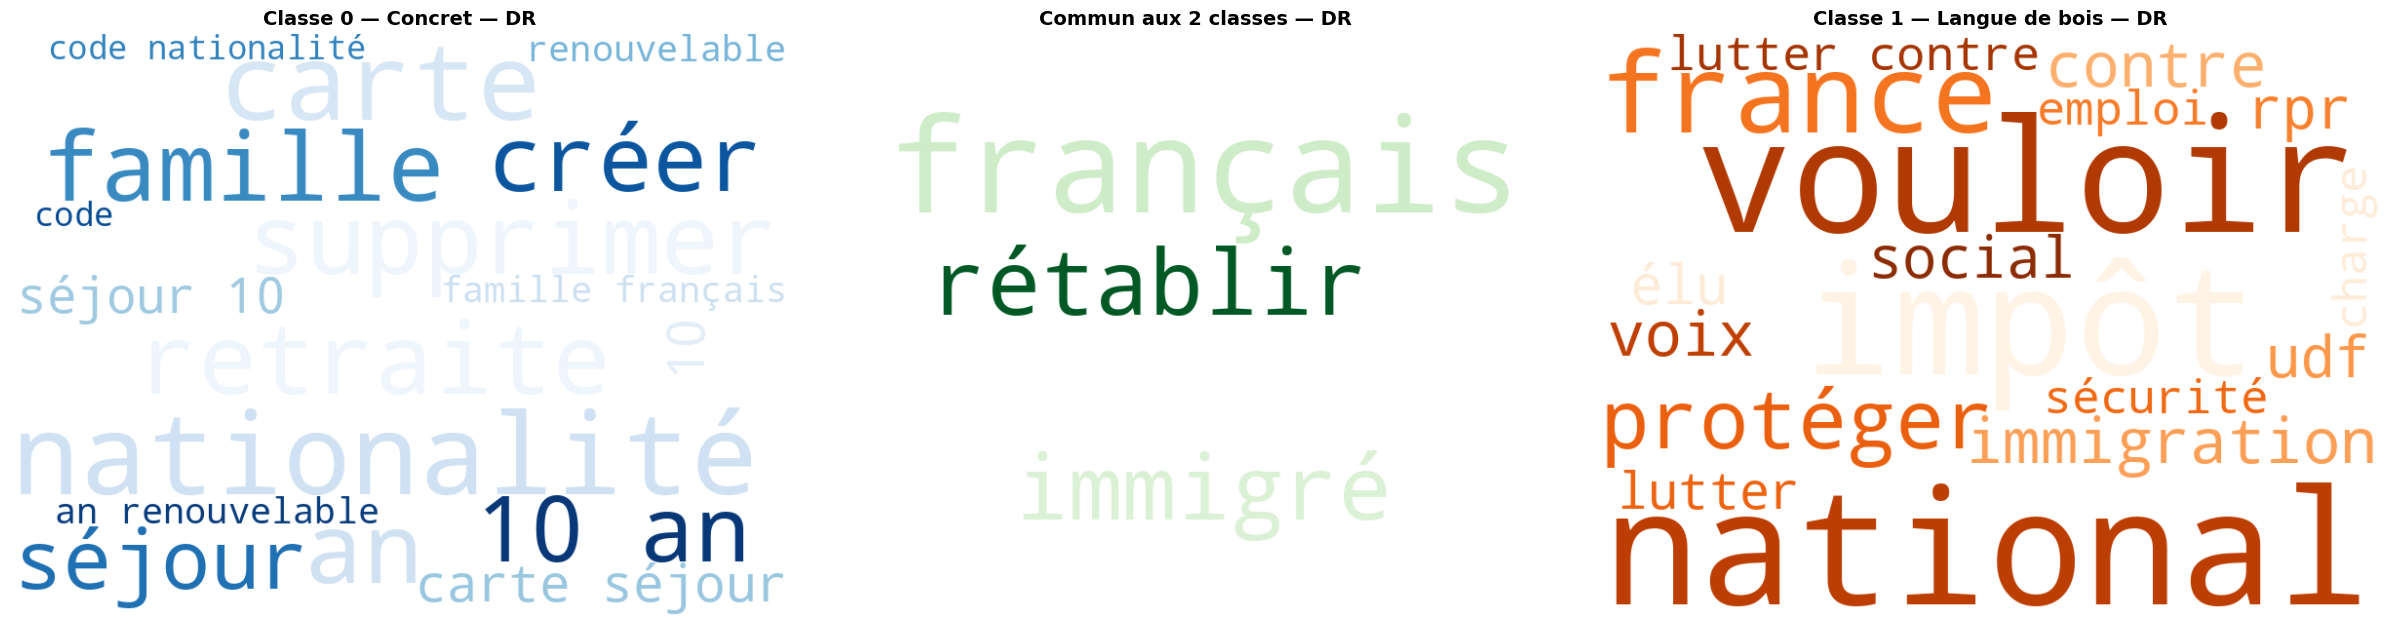

In [28]:
for orientation in ['GR', 'G', 'C', 'D', 'DR']:
    subset = df_train[df_train['Courant Politique'] == orientation]
    if len(subset[subset['Label'] == 0]) >= 5 and len(subset[subset['Label'] == 1]) >= 5:
        plot_wordclouds_contrastifs(subset, top_n=20, titre=orientation)

# II — Modèles baseline

In [29]:
colonne_texte     = 'texte_lemmatise'
colonnes_num      = [c for c in colonnes_numeriques if c in df_train.columns]

preprocesseur = ColumnTransformer(
    transformers=[
        ('texte', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95), colonne_texte),
        ('num',   RobustScaler(), colonnes_num)
    ],
    remainder='drop'
)
print("Dimensions X train :", preprocesseur.fit_transform(df_train).shape)

Dimensions X train : (1604, 2372)


## A) Régression logistique

In [30]:
pipeline_lr = Pipeline([
    ('pre', preprocesseur),
    ('clf', LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced', solver='liblinear'))
])
gs_lr = GridSearchCV(pipeline_lr,
    {'clf__C': [1, 2.5, 5, 7.5, 10, 12.5, 15], 'clf__penalty': ['l1', 'l2']},
    cv=StratifiedKFold(10, shuffle=True, random_state=42), scoring='f1', n_jobs=-1, verbose=1)
gs_lr.fit(df_train, df_train['Label'])

print(f"Meilleurs params : {gs_lr.best_params_}")
y_pred_lr = gs_lr.best_estimator_.predict(df_test)
print(classification_report(df_test['Label'], y_pred_lr))

Fitting 10 folds for each of 14 candidates, totalling 140 fits
Meilleurs params : {'clf__C': 12.5, 'clf__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       130
           1       0.87      0.81      0.84       272

    accuracy                           0.79       402
   macro avg       0.76      0.78      0.77       402
weighted avg       0.80      0.79      0.79       402



## B) Linear SVM

In [31]:
pipeline_svc = Pipeline([
    ('pre', preprocesseur),
    ('clf', LinearSVC(class_weight='balanced', max_iter=3000, random_state=42))
])
gs_svc = GridSearchCV(pipeline_svc,
    [{'clf__C': [0.1, 0.5, 1, 1.5], 'clf__penalty': ['l2'], 'clf__dual': [True]},
     {'clf__C': [0.01, 0.1, 1],      'clf__penalty': ['l1'], 'clf__dual': [False]}],
    cv=StratifiedKFold(10, shuffle=True, random_state=42), scoring='f1', n_jobs=-1, verbose=1)
gs_svc.fit(df_train, df_train['Label'])

print(f"Meilleurs params : {gs_svc.best_params_}")
y_pred_svc = gs_svc.best_estimator_.predict(df_test)
print(classification_report(df_test['Label'], y_pred_svc))

Fitting 10 folds for each of 7 candidates, totalling 70 fits
Meilleurs params : {'clf__C': 1, 'clf__dual': True, 'clf__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.64      0.75      0.69       130
           1       0.87      0.80      0.83       272

    accuracy                           0.78       402
   macro avg       0.76      0.77      0.76       402
weighted avg       0.80      0.78      0.79       402



## C) Random Forest

In [32]:
pipeline_rf = Pipeline([
    ('pre', preprocesseur),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
gs_rf = GridSearchCV(pipeline_rf,
    {'clf__n_estimators': [200, 300, 400], 'clf__max_depth': [5, 10, 15],
     'clf__min_samples_leaf': [1, 2, 4],   'clf__max_features': ['sqrt', 'log2']},
    cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1, verbose=1)
gs_rf.fit(df_train, df_train['Label'])

print(f"Meilleurs params : {gs_rf.best_params_}")
y_pred_rf = gs_rf.best_estimator_.predict(df_test)
print(classification_report(df_test['Label'], y_pred_rf))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Meilleurs params : {'clf__max_depth': 15, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
              precision    recall  f1-score   support

           0       0.72      0.52      0.60       130
           1       0.80      0.90      0.85       272

    accuracy                           0.78       402
   macro avg       0.76      0.71      0.73       402
weighted avg       0.77      0.78      0.77       402



## D) Comparaison baseline

                       F1 macro  F1 classe 0  F1 classe 1
Modèle                                                   
Benchmark constant        0.404        0.000        0.807
Régression Logistique     0.767        0.695        0.838
Linear SVM                0.762        0.690        0.834
Random Forest             0.725        0.604        0.846


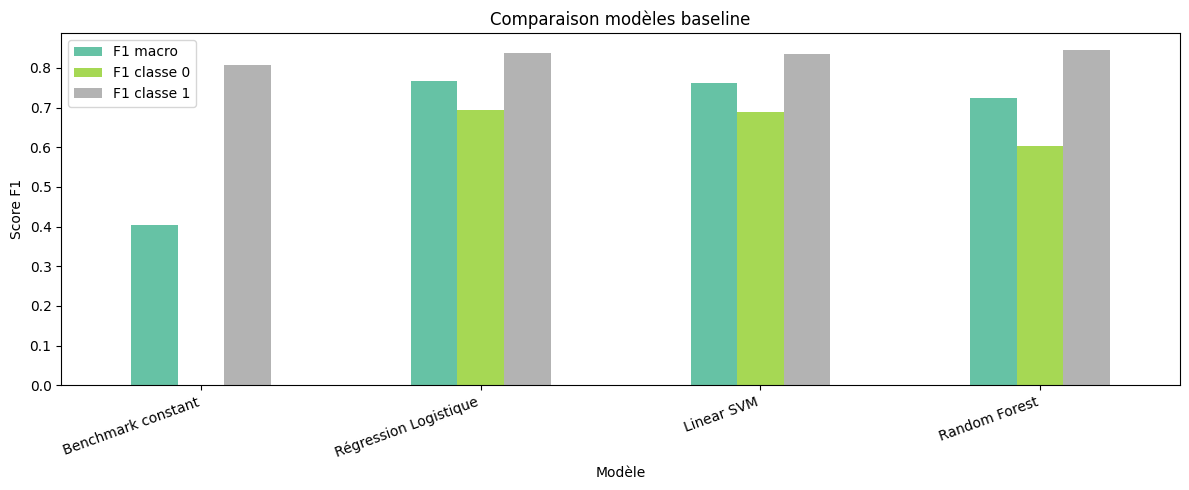

In [33]:
def scores(y_true, y_pred):
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    return {"F1 macro": f1_score(y_true, y_pred, average='macro', zero_division=0),
            "F1 classe 0": f1s[0], "F1 classe 1": f1s[1]}

res = pd.DataFrame([
    {"Modèle": "Benchmark constant",    **scores(df_test['Label'], np.ones(len(df_test), dtype=int))},
    {"Modèle": "Régression Logistique", **scores(df_test['Label'], y_pred_lr)},
    {"Modèle": "Linear SVM",            **scores(df_test['Label'], y_pred_svc)},
    {"Modèle": "Random Forest",         **scores(df_test['Label'], y_pred_rf)},
]).set_index("Modèle").round(3)

print(res.to_string())
res.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title("Comparaison modèles baseline")
plt.ylabel("Score F1")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# III — CamemBERT (fine-tuning)

On fine-tune `camembert-base` (RoBERTa pré-entraîné sur du français) sur notre tâche binaire. Le modèle tourne sur GPU Colab (T4/A100).

In [47]:
from transformers import (
    CamembertTokenizer,
    CamembertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset

MODEL_NAME = "camembert-base"
MAX_LEN    = 256

tokenizer = CamembertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer chargé. Device : {device}")

Tokenizer chargé. Device : cuda


In [48]:
class LDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def nettoyer(texte):
    if pd.isna(texte): return ""
    texte = re.sub(r'Sciences Po.*?CEVIPOF', '', str(texte), flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', texte).strip()


train_dataset = LDBDataset(df_train['Texte'].apply(nettoyer), df_train['Label'], tokenizer, MAX_LEN)
test_dataset  = LDBDataset(df_test['Texte'].apply(nettoyer),  df_test['Label'],  tokenizer, MAX_LEN)
print(f"Train : {len(train_dataset)} | Test : {len(test_dataset)}")

Train : 1604 | Test : 402


In [49]:
# Poids de classe pour compenser le déséquilibre
n_total = len(df_train)
n_0 = (df_train['Label'] == 0).sum()
n_1 = (df_train['Label'] == 1).sum()
class_weights = torch.tensor(
    [n_total / (2 * n_0), n_total / (2 * n_1)], dtype=torch.float
).to(device)
print(f"Poids : classe 0 → {class_weights[0]:.2f} | classe 1 → {class_weights[1]:.2f}")


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1s   = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro":    f1_score(labels, preds, average='macro'),
        "f1_classe_0": f1s[0],
        "f1_classe_1": f1s[1],
        "accuracy":    accuracy_score(labels, preds)
    }

Poids : classe 0 → 1.55 | classe 1 → 0.74


In [50]:
model = CamembertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

training_args = TrainingArguments(
    output_dir             = "./camembert_ldb",
    num_train_epochs       = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate          = 2e-5,
    weight_decay           = 0.01,
    warmup_ratio           = 0.1,
    eval_strategy          = "epoch",
    save_strategy          = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model  = "f1_macro",
    greater_is_better      = True,
    logging_steps          = 50,
    report_to              = "none",
    seed                   = 42
)

trainer = WeightedTrainer(
    model          = model,
    args           = training_args,
    train_dataset  = train_dataset,
    eval_dataset   = test_dataset,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=2)]
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [51]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Classe 0,F1 Classe 1,Accuracy
1,0.493710,0.442636,0.800010,0.753247,0.846774,0.810945
2,0.395024,0.417273,0.815980,0.755556,0.876404,0.835821
3,0.338143,0.451989,0.813633,0.761246,0.866019,0.828358
4,0.307486,0.469365,0.807038,0.750877,0.863198,0.823383


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=404, training_loss=0.3965791983179527, metrics={'train_runtime': 208.9995, 'train_samples_per_second': 38.373, 'train_steps_per_second': 2.416, 'total_flos': 365979255785280.0, 'train_loss': 0.3965791983179527, 'epoch': 4.0})

In [52]:
preds_out = trainer.predict(test_dataset)
y_pred_camembert = np.argmax(preds_out.predictions, axis=-1)

print("Rapport CamemBERT :")
print(classification_report(df_test['Label'], y_pred_camembert,
                            target_names=['0 (Concret)', '1 (Langue de bois)']))
print("Matrice de confusion :")
print(confusion_matrix(df_test['Label'], y_pred_camembert, normalize='true').round(3))

Rapport CamemBERT :
                    precision    recall  f1-score   support

       0 (Concret)       0.73      0.78      0.76       130
1 (Langue de bois)       0.89      0.86      0.88       272

          accuracy                           0.84       402
         macro avg       0.81      0.82      0.82       402
      weighted avg       0.84      0.84      0.84       402

Matrice de confusion :
[[0.785 0.215]
 [0.14  0.86 ]]


                       F1 macro  F1 classe 0  F1 classe 1
Modèle                                                   
Benchmark constant        0.404        0.000        0.807
Régression Logistique     0.767        0.695        0.838
Linear SVM                0.762        0.690        0.834
Random Forest             0.725        0.604        0.846
CamemBERT (fine-tuné)     0.816        0.756        0.876


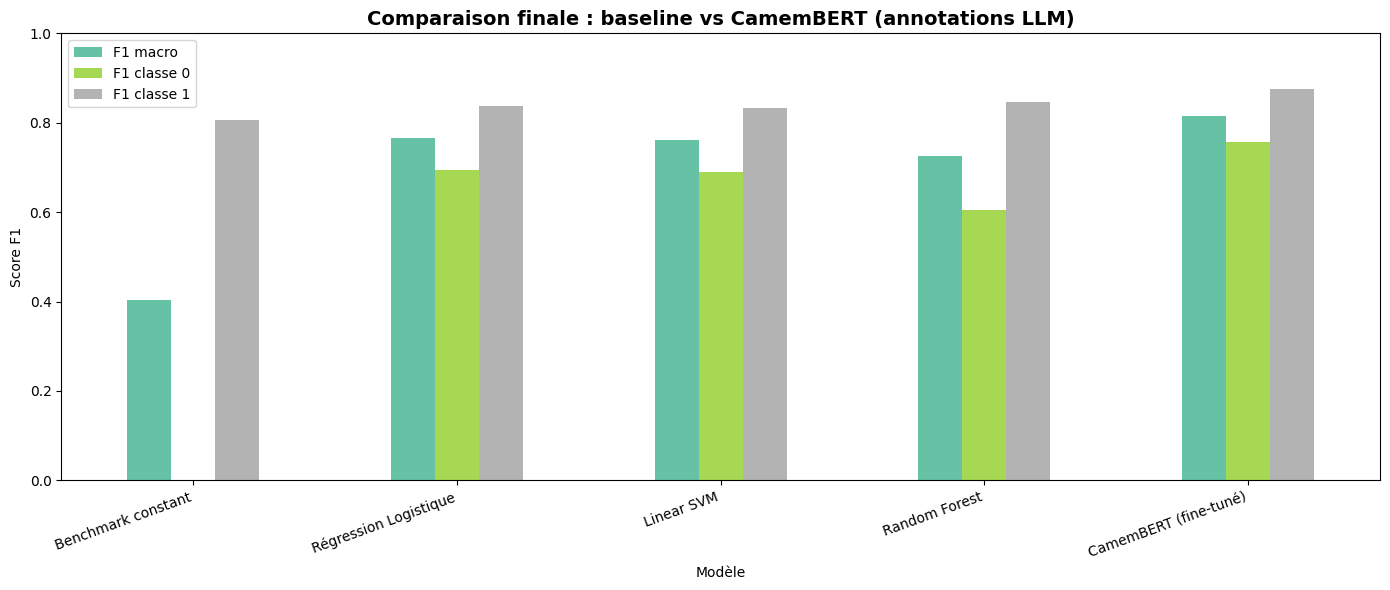

In [53]:
# Tableau comparatif final
res_final = pd.DataFrame([
    {"Modèle": "Benchmark constant",    **scores(df_test['Label'], np.ones(len(df_test), dtype=int))},
    {"Modèle": "Régression Logistique", **scores(df_test['Label'], y_pred_lr)},
    {"Modèle": "Linear SVM",            **scores(df_test['Label'], y_pred_svc)},
    {"Modèle": "Random Forest",         **scores(df_test['Label'], y_pred_rf)},
    {"Modèle": "CamemBERT (fine-tuné)", **scores(df_test['Label'], y_pred_camembert)},
]).set_index("Modèle").round(3)

print(res_final.to_string())
res_final.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title("Comparaison finale : baseline vs CamemBERT (annotations LLM)", fontsize=14, fontweight='bold')
plt.ylabel("Score F1")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [54]:
# Analyse des erreurs
df_errors = df_test.copy().reset_index(drop=True)
df_errors['pred'] = y_pred_camembert

fp = df_errors[(df_errors['Label'] == 0) & (df_errors['pred'] == 1)]
fn = df_errors[(df_errors['Label'] == 1) & (df_errors['pred'] == 0)]

print(f"Faux positifs (concret → prédit langue de bois) : {len(fp)}")
for _, r in fp.head(3).iterrows():
    print(f"  [{r['Courant Politique']}] {r['Texte'][:120]}...")

print(f"\nFaux négatifs (langue de bois → prédit concret) : {len(fn)}")
for _, r in fn.head(3).iterrows():
    print(f"  [{r['Courant Politique']}] {r['Texte'][:120]}...")

Faux positifs (concret → prédit langue de bois) : 28
  [C] Cette voie, je m'y suis engagé en tant que Maire depuis 1989, mais aussi au Conseil Général où avec l'ensemble de l'oppo...
  [GR] L'école doit se décharger de la formation professionnelle au profit d'une prise en charge par les entreprises elles-même...
  [GR] Pour notre environnement, il faut créer des logements de qualité à des prix en rapport avec les salaires et construire u...

Faux négatifs (langue de bois → prédit concret) : 38
  [DR] Réduire les impôts en mettant fin aux gaspillages de l'argent public et en supprimant progressivement l'impôt sur le rev...
  [DR] Ils promettent de sauver l'agriculture, mais le RPR et l'UDF ont approuvé la PAC 92 et ont dit oui au Traité de Maastric...
  [DR] Le RPR et l'UDF prétendent être contre l'immigration, mais avec le PS et le PC, ils ont voté la carte de séjour de 10 an...


In [55]:
# Sauvegarde du modèle
trainer.save_model("./camembert_ldb_final")
tokenizer.save_pretrained("./camembert_ldb_final")
print("Modèle sauvegardé dans ./camembert_ldb_final")

# Sur Colab : télécharger le modèle
if IN_COLAB:
    import shutil
    shutil.make_archive("camembert_ldb_final", 'zip', "./camembert_ldb_final")
    files.download("camembert_ldb_final.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans ./camembert_ldb_final


NameError: name 'IN_COLAB' is not defined

# IV — Évaluation out-of-sample sur toutes les annotations humaines

On charge les 3 fichiers d'annotations individuels, on les concatène et on teste tous les modèles entraînés sur les annotations LLM sur ce corpus humain. C'est le vrai benchmark de généralisation.

In [86]:
# Chargement des 3 datasets humains
df_h  = pd.read_excel("../annotations finales/annotations Henri.xlsx").assign(source='Henri')
df_j  = pd.read_excel("../annotations finales/annotations JL.xlsx").assign(source='JL')
df_ju = pd.read_excel("../annotations finales/annotations Julien.xlsx").assign(source='Julien')

df_humain = pd.concat([df_h, df_j, df_ju], ignore_index=True)
df_humain = df_humain.drop_duplicates(subset=['Texte'], keep='first')
df_humain.columns = ['Parti', 'Courant Politique', 'Texte', 'Label', 'source']

print(f"Dataset humain complet : {len(df_humain)} textes")
print(f"Distribution labels :")
print(df_humain['Label'].value_counts())
print(f"Proportion langue de bois : {df_humain['Label'].mean():.2f}")

Dataset humain complet : 957 textes
Distribution labels :
Label
1    660
0    297
Name: count, dtype: int64
Proportion langue de bois : 0.69


In [87]:
# Feature engineering sur le dataset humain (même pipeline que le train LLM)
df_humain[colonnes_extraites] = df_humain['Texte'].progress_apply(extraire_toutes_features)
df_humain = appliquer_features_lexicales(df_humain, vocab_0, vocab_1)

# Winsorisation avec les seuils calculés sur df_train
for col in ['densite_ponct_interne', 'densite_futur_cond']:
    if col in df_humain.columns:
        seuil = df_train[col].quantile(0.99)
        df_humain[col] = np.clip(df_humain[col], None, seuil)

print("Features extraites.")

  0%|          | 0/957 [00:00<?, ?it/s]

Features extraites.


In [88]:
# Prédictions des modèles baseline sur le dataset humain
y_true_h = df_humain['Label']

y_pred_lr_h  = gs_lr.best_estimator_.predict(df_humain)
y_pred_svc_h = gs_svc.best_estimator_.predict(df_humain)
y_pred_rf_h  = gs_rf.best_estimator_.predict(df_humain)

print("=== Régression Logistique ===")
print(classification_report(y_true_h, y_pred_lr_h))
print("=== Linear SVM ===")
print(classification_report(y_true_h, y_pred_svc_h))
print("=== Random Forest ===")
print(classification_report(y_true_h, y_pred_rf_h))

=== Régression Logistique ===
              precision    recall  f1-score   support

           0       0.64      0.60      0.62       297
           1       0.83      0.85      0.84       660

    accuracy                           0.77       957
   macro avg       0.74      0.73      0.73       957
weighted avg       0.77      0.77      0.77       957

=== Linear SVM ===
              precision    recall  f1-score   support

           0       0.64      0.60      0.62       297
           1       0.83      0.85      0.84       660

    accuracy                           0.77       957
   macro avg       0.74      0.73      0.73       957
weighted avg       0.77      0.77      0.77       957

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.79      0.37      0.50       297
           1       0.77      0.96      0.85       660

    accuracy                           0.77       957
   macro avg       0.78      0.66      0.68       957
wei

In [89]:
# Prédiction CamemBERT sur le dataset humain
humain_dataset = LDBDataset(df_humain['Texte'].apply(nettoyer), df_humain['Label'], tokenizer, MAX_LEN)
preds_h = trainer.predict(humain_dataset)
y_pred_camembert_h = np.argmax(preds_h.predictions, axis=-1)

print("=== CamemBERT ===")
print(classification_report(y_true_h, y_pred_camembert_h,
                            target_names=['0 (Concret)', '1 (Langue de bois)']))

=== CamemBERT ===
                    precision    recall  f1-score   support

       0 (Concret)       0.69      0.79      0.74       297
1 (Langue de bois)       0.90      0.84      0.87       660

          accuracy                           0.83       957
         macro avg       0.80      0.82      0.80       957
      weighted avg       0.84      0.83      0.83       957



=== Performances out-of-sample (annotations humaines) ===
                       F1 macro  F1 classe 0  F1 classe 1
Modèle                                                   
Benchmark constant        0.408        0.000        0.816
Régression Logistique     0.730        0.621        0.838
Linear SVM                0.730        0.623        0.838
Random Forest             0.677        0.501        0.853
CamemBERT (fine-tuné)     0.804        0.739        0.869


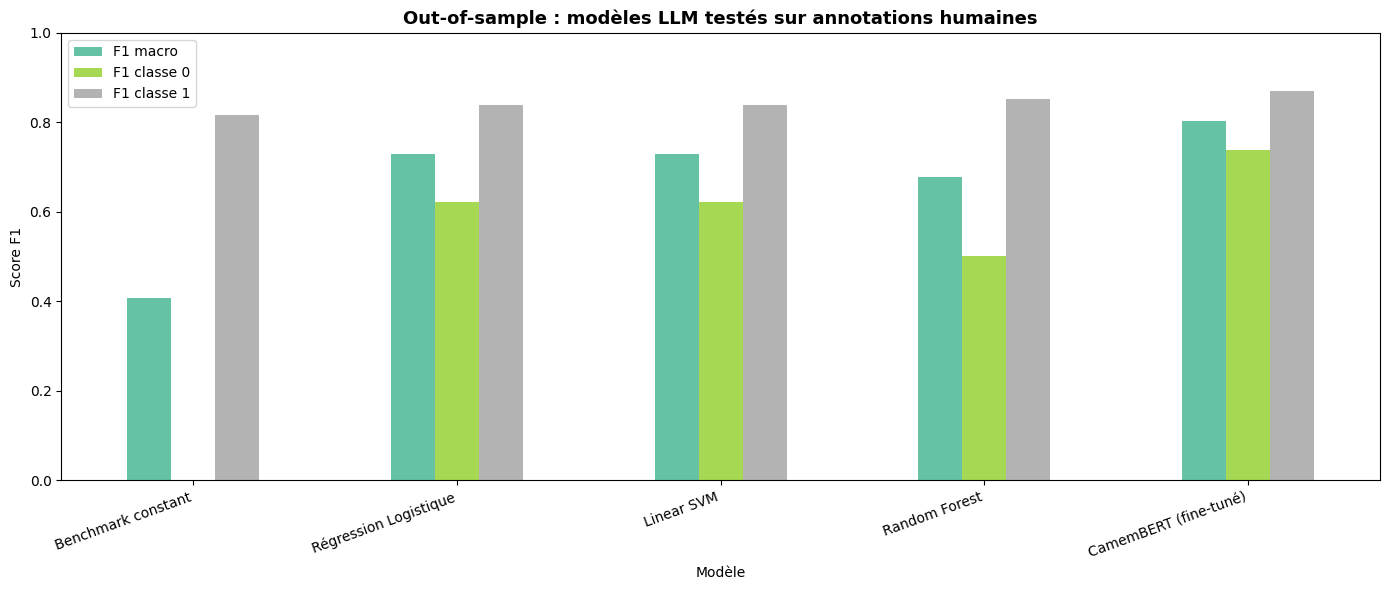

In [90]:
# Tableau comparatif final — out-of-sample sur annotations humaines
res_oos = pd.DataFrame([
    {"Modèle": "Benchmark constant",    **scores(y_true_h, np.ones(len(y_true_h), dtype=int))},
    {"Modèle": "Régression Logistique", **scores(y_true_h, y_pred_lr_h)},
    {"Modèle": "Linear SVM",            **scores(y_true_h, y_pred_svc_h)},
    {"Modèle": "Random Forest",         **scores(y_true_h, y_pred_rf_h)},
    {"Modèle": "CamemBERT (fine-tuné)", **scores(y_true_h, y_pred_camembert_h)},
]).set_index("Modèle").round(3)

print("=== Performances out-of-sample (annotations humaines) ===")
print(res_oos.to_string())

res_oos.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title("Out-of-sample : modèles LLM testés sur annotations humaines", fontsize=13, fontweight='bold')
plt.ylabel("Score F1")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()